# Plotting of Piezoelectric Results

In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import matplotlib.ticker as ticker
from scipy.stats import pearsonr
import yaml
%matplotlib inline
from pathlib import Path
NOTEBOOK_DIR = Path().resolve()
print (NOTEBOOK_DIR)
ROOT = NOTEBOOK_DIR.parent  # go up one level

print("ROOT:", ROOT)
config = yaml.safe_load(open(ROOT / "config.yaml"))
cm=1/2.54

results_file= ROOT/config["resultsmaindir"]/"struct_bec_totale_all.xlsx"

/Users/srinidhi/Desktop/chatgpt_analysis/gitpractice/piezoelectric_screening/notebooks
ROOT: /Users/srinidhi/Desktop/chatgpt_analysis/gitpractice/piezoelectric_screening


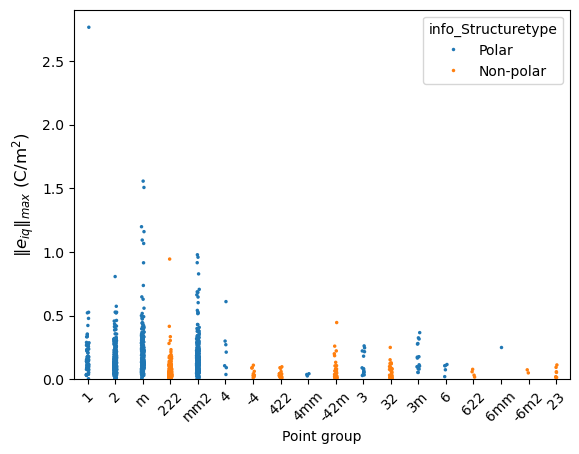

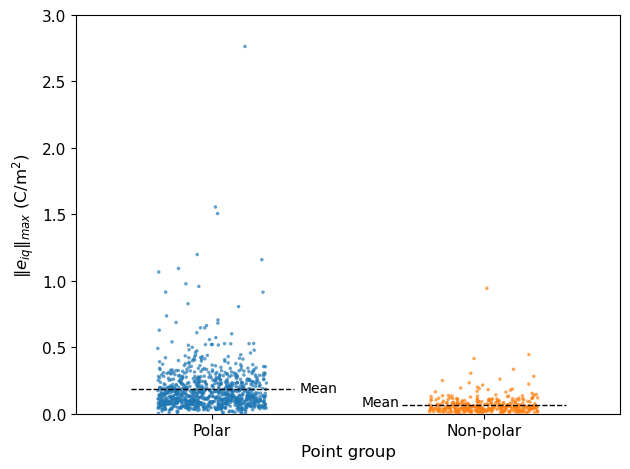

In [11]:
def evspointgroup(results_file):
    """ Plotting converged structure results 'e' vs point group"""
    df_totale_edited = pd.read_excel(results_file, engine="openpyxl")

    df_totale_converged=df_totale_edited.query('`info_ClampedDynamic_convergence`=="Converged" & `info_qmofcsdequal?`=="equal"')
    fig1, ax1 = plt.subplots()
    sns.stripplot(x=df_totale_converged['info_PointGroup'], y=df_totale_converged[
        'info_TotaleNorm'], hue=df_totale_converged["info_Structuretype"],
                  order=['1','2','m','222','mm2','4','-4', '422','4mm','-42m','3','32','3m',
                         '6', '622','6mm','-6m2','23'],jitter=0.05,size=2.5,ax=ax1)
    #sns.violinplot(x=df_totale_converged['info_PointGroup'], y=df_totale_converged['info_TotaleNorm'], hue=df_totale_converged["info_Structuretype"], jitter=0.05, size=2.5,cut=0,linewidth=1.0)
    ax1.set_ylim(bottom=0)
    ax1.tick_params(axis='x',labelrotation=45)
    ax1.set_ylabel(r"$\Vert e_{iq}\Vert_{max}$ (C/m$^2$)",fontsize=12.0)
    ax1.set_xlabel("Point group")
    #ax1.set_yscale("log")
    #plt.savefig('../Figures/violinallexceptZnCuCd_TotaleVsPointgroup',dpi=600)
    #fig1.savefig('../Figures/allexceptZnCuCd_TotaleVsPointgroup',dpi=600)
    fig2,ax2=plt.subplots()
    variables = dict(x=df_totale_converged['info_Structuretype'], y=df_totale_converged['info_TotaleNorm'])
    sns.stripplot(x=df_totale_converged['info_Structuretype'],y=df_totale_converged['info_TotaleNorm'],hue=df_totale_converged["info_Structuretype"],jitter=0.2,size=2.5,alpha=0.7,ax=ax2)
    sns.boxplot(showmeans=True,meanline=True,meanprops={'color': 'k', 'ls': '--', 'lw': 1},medianprops={'visible': False},whiskerprops={'visible': False},zorder=10,x=df_totale_converged['info_Structuretype'],y=df_totale_converged['info_TotaleNorm'],showfliers=False,showbox=False,showcaps=False,
            ax=ax2,width=0.6)
    # sns.violinplot(x=df_totale_converged['info_Structuretype'],y=df_totale_converged['info_TotaleNorm'],cut=0,ax=ax2)
    #ax2.set_yscale("log")
    ax2.annotate("Mean",(0.32,0.167))
    ax2.annotate("Mean", (0.55, 0.057))
    ax2.set_ylim((0,3.0))
    ax2.set_ylabel(r"$\Vert e_{iq}\Vert_{max}$ (C/m$^2$)",fontsize=12.0)
    ax2.set_xlabel("Point group",fontsize=12.0)
    ax2.tick_params(axis='both', which='major', labelsize=11.0)
    plt.tight_layout()
    #fig2.savefig('../Figures/TotaleVsPolarNonpolar', dpi=600)

evspointgroup(results_file)

0.3740621947876891 0.9462359964407008
0.11752646313021087


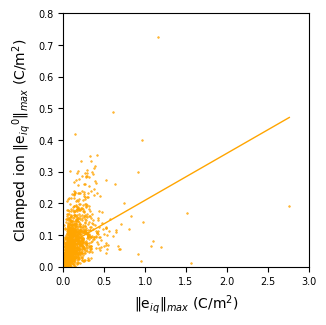

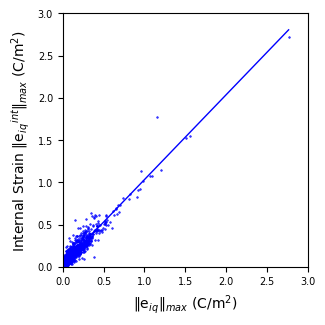

In [17]:
def explodedcolumns(df_mergedinfo_all):
    grp_info_plot=[]
    BEC_metal_plot=[]
    oxidation_number_plot=[]
    metal_atnumber_plot=[]
    mofcode_plot=[]

    temp=(df_mergedinfo_all.assign(metal_groupinfo=df_mergedinfo_all.metal_groupinfo.str.split(',')).explode('metal_groupinfo'))
    grp_info=np.asarray(temp['metal_groupinfo'])
    for i in grp_info:
        i=re.sub(r"[\]\[\']","",i)
        grp_info_plot.append(i.strip())

    temp=(df_mergedinfo_all.assign(BEC_metalavg=df_mergedinfo_all.BEC_metalavg.str.split(',')).explode('BEC_metalavg'))
    BEC_metal=np.asarray(temp['BEC_metalavg'])
    for j in BEC_metal:
        j=re.sub(r"[\]\[]","",j)
        j=j.strip()
        j=float(j)
        BEC_metal_plot.append(j)

    temp=(df_mergedinfo_all.assign(oxidation_num=df_mergedinfo_all.oxidation_num.str.split(',')).explode('oxidation_num'))
    oxidation_number=np.asarray(temp['oxidation_num'])
    for j in oxidation_number:
        j=re.sub(r"[\]\[]","",j)
        j=j.strip()
        j=int(j)
        oxidation_number_plot.append(j)

    temp=(df_mergedinfo_all.assign(metal_atno=df_mergedinfo_all.metal_atno.str.split(',')).explode('metal_atno'))
    metal_atnumber=np.asarray(temp['metal_atno'])
    for j in metal_atnumber:
        j=re.sub(r"[\]\[]","",j)
        j=j.strip()
        j=int(j)
        metal_atnumber_plot.append(j)

    temp = (df_mergedinfo_all.assign(info_MOFCode=df_mergedinfo_all.info_MOFCode.str.split(',')).explode('info_MOFCode'))
    temp_e = (df_mergedinfo_all.assign(info_TotaleNorm=df_mergedinfo_all.info_TotaleNorm).explode('info_TotaleNorm'))
    temp_clampede = (df_mergedinfo_all.assign(info_ClampedNorm=df_mergedinfo_all.info_ClampedNorm).explode('info_ClampedNorm'))
    temp_dynamice = (df_mergedinfo_all.assign(info_DynamicNorm=df_mergedinfo_all.info_DynamicNorm).explode('info_DynamicNorm'))
    temp_density = (df_mergedinfo_all.assign(info_density=df_mergedinfo_all.info_density).explode('info_density'))
    #print (temp)
    mofcode = np.asarray(temp['info_MOFCode'])
    totalenorm=np.asarray(temp_e['info_TotaleNorm'])
    clampednorm = np.asarray(temp_clampede['info_ClampedNorm'])
    dynamicnorm = np.asarray(temp_dynamice['info_DynamicNorm'])
    density=np.asarray(temp_density['info_density'])
    grp=np.asarray(df_mergedinfo_all["metal_atno"])
    temp_atno=[]
    mofcode_plot=[]
    mofcode_grtthan1metal=[]
    totalenorm_grtthan1metal=[]
    totalenorm_plot=[]
    clampednorm_plot = []
    dynamicnorm_plot = []
    density_plot=[]
    for num,val in enumerate(grp):
        val=re.sub(r"[\]\[]","",val)
        if len(val)<=2:
            temp_atno.append(val)
            mofcode_plot.append(mofcode[num])
            totalenorm_plot.append(totalenorm[num])
            clampednorm_plot.append(clampednorm[num])
            dynamicnorm_plot.append(dynamicnorm[num])
            density_plot.append(density[num])
        if len(val)>2:
            my_val=val.split(",")
            for l in range(len(my_val)):
                temp_atno.append(my_val[l])
                mofcode_plot.append(mofcode[num])
                totalenorm_plot.append(totalenorm[num])
                clampednorm_plot.append(clampednorm[num])
                dynamicnorm_plot.append(dynamicnorm[num])
                density_plot.append(density[num])
        if len(val)>2:
            my_val = val.split(",")
            for l in range(len(my_val)):
                temp_atno.append(my_val[l])
                mofcode_grtthan1metal.append(mofcode[num])
                totalenorm_grtthan1metal.append(totalenorm[num])
    return grp_info_plot, BEC_metal_plot,oxidation_number_plot, metal_atnumber_plot,mofcode_plot,totalenorm_plot,clampednorm_plot,dynamicnorm_plot,density_plot,mofcode_grtthan1metal,totalenorm_grtthan1metal

def clampeddynamic_e(results_file):
    df_mergedinfo_all = pd.read_excel(results_file, engine="openpyxl")
    df_mergedinfo_all = df_mergedinfo_all.query('`info_ClampedDynamic_convergence`=="Converged" & `info_qmofcsdequal?`=="equal"')
    grp_info_plot, BEC_metal_plot, oxidation_number_plot, metal_atnumber_plot, mofcode_plot, totalenorm_plot,clampednorm_plot,dynamicnorm_plot,density_plot, mofcode_grtthan1metal,totalenorm_grtthan1metal = explodedcolumns(df_mergedinfo_all)
    fig1, ax1 = plt.subplots(figsize=(8.3*cm,8.3*cm))
    fig2, ax2 = plt.subplots(figsize=(8.3 * cm, 8.3 * cm))
    sns.regplot(y=df_mergedinfo_all["info_DynamicNorm"], x=df_mergedinfo_all["info_TotaleNorm"],ci=None,color="blue",marker="o",scatter_kws={"s":1.5,"linewidths":0.5,"alpha":0.75},line_kws={"lw":1},ax=ax2)
    sns.regplot(y=df_mergedinfo_all["info_ClampedNorm"], x=df_mergedinfo_all["info_TotaleNorm"],ci=None,color="orange",marker="o",scatter_kws={"s":1.5,"linewidths":0.5,"alpha":0.75},line_kws={"lw":1},ax=ax1)
    
    fig1.tight_layout()
    fig2.tight_layout()
    for axs in [ax1,ax2]:
        axs.tick_params(axis='both', labelsize=7.0)
        axs.set_xlim((0,3.0))
        axs.set_ylim(bottom=0)
        #axs.set_ylim(top=1.8)
        axs.set_xlabel(r"$\Vert$e$_i$$_q$$\Vert$$_{max}$ (C/m$^2$)", fontsize=10.0)
    ax1.set_ylim(top=0.8)
    ax2.set_ylim(top=3.0)
    ax2.set_ylabel(r"Internal Strain $\Vert$e$_i$$_q$$^{int}$$\Vert$$_{max}$ (C/m$^2$)", fontsize=10.0)
    ax1.set_ylabel(r"Clamped ion $\Vert$e$_i$$_q$$^{0}$$\Vert$$_{max}$ (C/m$^2$)", fontsize=10.0)
    corr1,_= pearsonr(df_mergedinfo_all["info_ClampedNorm"],df_mergedinfo_all["info_TotaleNorm"])
    corr2, _ = pearsonr(df_mergedinfo_all["info_DynamicNorm"], df_mergedinfo_all["info_TotaleNorm"])
    corr3, _ = pearsonr(BEC_metal_plot, dynamicnorm_plot)
    print (corr1,corr2)
    print (corr3)

clampeddynamic_e(results_file)

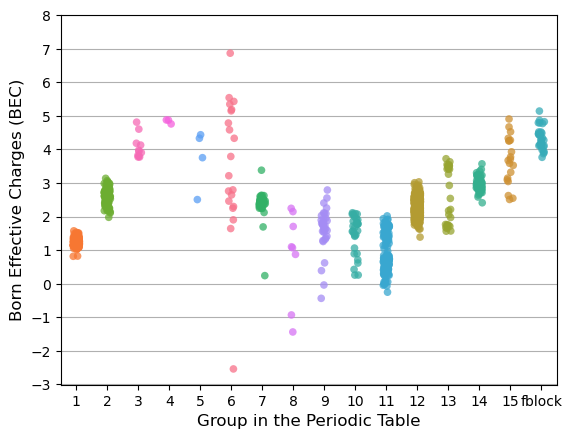

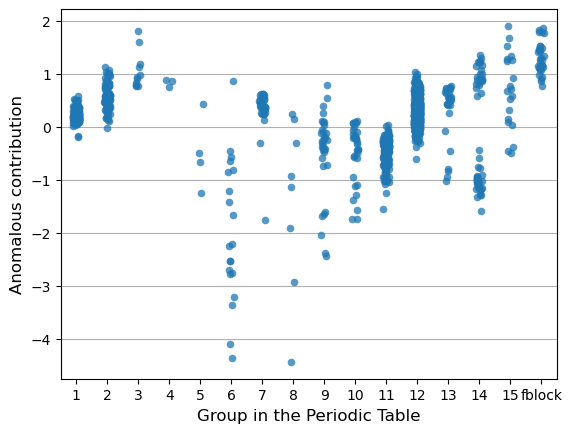

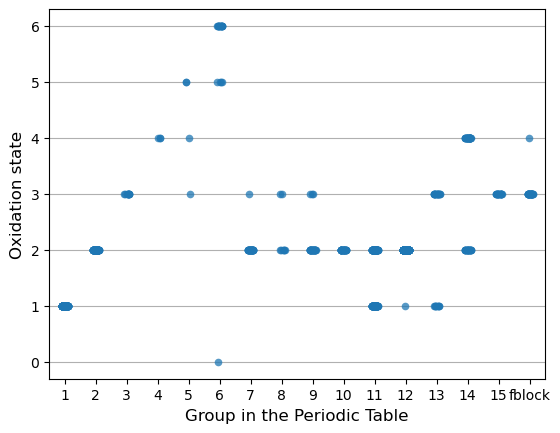

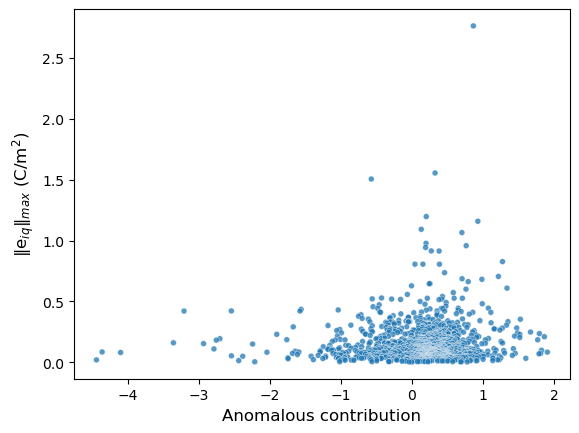

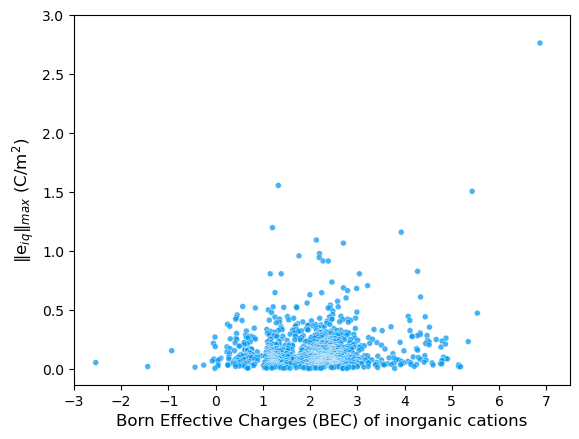

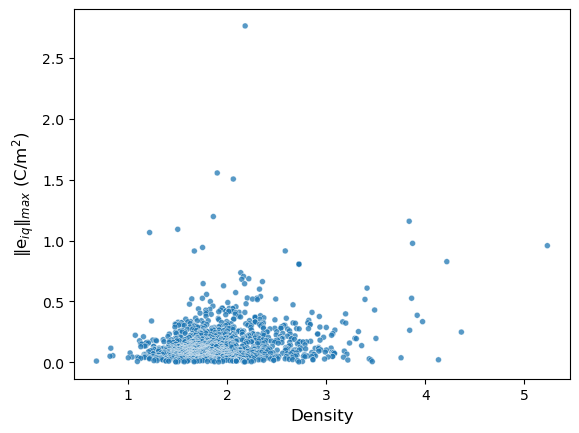

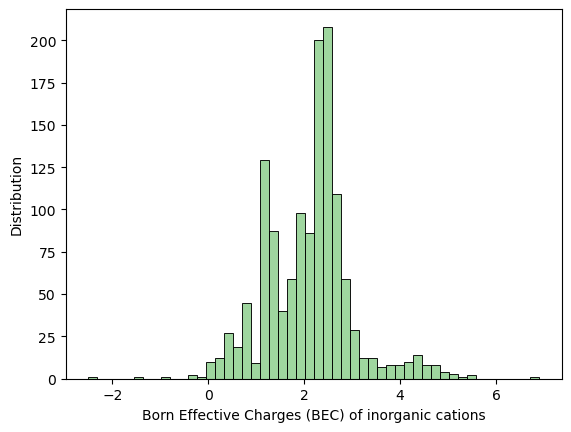

In [20]:
def groupvsanomcharge(results_file):
    df_mergedinfo_all=pd.read_excel(results_file,engine="openpyxl")
    df_mergedinfo_all=df_mergedinfo_all.drop(['Unnamed: 0','e11', 'e12', 'e13', 'e14', 'e15', 'e16', 'e21', 'e22', 'e23', 'e24', 'e25', 'e26', 'e31', 'e32', 'e33', 'e34', 'e35', 'e36','info_optnetmagmom', 'info_piezonetmagmom'],axis=1)
    df_mergedinfo_all=df_mergedinfo_all.query('`info_ClampedDynamic_convergence`=="Converged" & `info_qmofcsdequal?`=="equal"')
    #print (df_mergedinfo_all["oxidation_num"])
    grp_info_plot, BEC_metal_plot,oxidation_number_plot, metal_atnumber_plot,mofcode_plot,totalenorm_plot,clampednorm_plot,dynamicnorm_plot,density_plot,mofcode_grtthan1metal,totalenorm_grtthan1metal=explodedcolumns(df_mergedinfo_all)
    BEC_metal_plot=np.asarray(BEC_metal_plot)
    oxidation_number_plot=np.asarray(oxidation_number_plot)
    density_plot=np.asarray(density_plot)
    fig1,ax1=plt.subplots()
    fig2,ax2=plt.subplots()
    fig3, ax3 = plt.subplots()

    #sns.set_theme(style="ticks")
    sns.stripplot(x=grp_info_plot, y=BEC_metal_plot-oxidation_number_plot,
                  order=["1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12", "13", "14", "15", "fblock"], alpha=0.75, size=5.5,ax=ax2)
    sns.stripplot(x=grp_info_plot, y=BEC_metal_plot,hue=grp_info_plot,
                  order=["1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12", "13", "14", "15", "fblock"], alpha=0.75, size=5.5,ax=ax1)
    sns.stripplot(x=grp_info_plot, y=oxidation_number_plot,
                  order=["1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12", "13", "14", "15", "fblock"], alpha=0.75, size=5.5, ax=ax3)
    for axs in [ax1,ax2,ax3]:
        axs.set_xlabel("Group in the Periodic Table",fontsize=12.0)
        axs.grid(axis="y")
        axs.tick_params(axis='both', which='major', labelsize=10.0)
        #axs.set_xticks(axs.get_xticks())
        #axs.set_xticklabels(axs.get_xticklabels(), rotation=10, ha='right')
    ax1.set_yticks(np.arange(-3, 9, 1.0))
    ax1.set_ylabel("Born Effective Charges (BEC)",fontsize=12.0)
    ax2.set_ylabel("Anomalous contribution",fontsize=12.0)
    ax3.set_ylabel("Oxidation state",fontsize=12.0)
    fig4, ax4 = plt.subplots()
    sns.scatterplot(x=BEC_metal_plot-oxidation_number_plot, y=totalenorm_plot,size=3.5,legend=False,alpha=0.75,ax=ax4)
    #ax4.set(yscale="log")
    fig5,ax5=plt.subplots()
    sns.scatterplot(x=BEC_metal_plot, y=totalenorm_plot, size=2.5, color='#069AF3',legend=False,alpha=0.75,ax=ax5)
    #ax5.set(yscale="log")
    fig6, ax6 = plt.subplots()
    sns.scatterplot(x=density_plot, y=totalenorm_plot, size=3.0, legend=False, alpha=0.75, ax=ax6)

    ax4.set_xlabel("Anomalous contribution", fontsize=12.0)
    ax4.set_ylabel(r"$\Vert$e$_i$$_q$$\Vert$$_{max}$ (C/m$^2$)", fontsize=12.0)
    ax5.set_xlabel("Born Effective Charges (BEC) of inorganic cations", fontsize=12.0)
    ax5.set_ylabel(r"$\Vert$e$_i$$_q$$\Vert$$_{max}$ (C/m$^2$)", fontsize=12.0)
    ax6.set_xlabel("Density", fontsize=12.0)
    ax6.set_ylabel(r"$\Vert$e$_i$$_q$$\Vert$$_{max}$ (C/m$^2$)", fontsize=12.0)
    # ax4.set_yticks(np.arange(0,4.5,0.5))
    ax5.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax5.set_xlim((-3,7.5))
    ax5.set_ylim(top=3.0)
    ax5.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
    #plt.show()
    
    """BEC distribution"""
    figh,axh=plt.subplots()
    BEC_metal_plot=(np.around(BEC_metal_plot,decimals=1))
    #print (np.max(BEC_metal_plot))
    sns.histplot(x=BEC_metal_plot,bins=50,ax=axh,color="#7fc97f",edgecolor='black')
    #plt.hist(x=BEC_metal_plot, bins=100, color="#7fc97f")
    #axh.set_xticks(np.arange(np.min(BEC_metal_plot),np.max(BEC_metal_plot),1))
    axh.set_xlabel("Born Effective Charges (BEC) of inorganic cations")
    axh.set_ylabel("Distribution")
    #plt.show()

groupvsanomcharge(results_file)